# Behavior-Centered Vectorization
## Get largest R-sq source monkey for each behavior and vectorize (6-dim)

In [39]:
import os


%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/directional_linear_regression_on_single_neurons_low_variance_removed.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]
print(significant_results.shape)

(2768, 7)


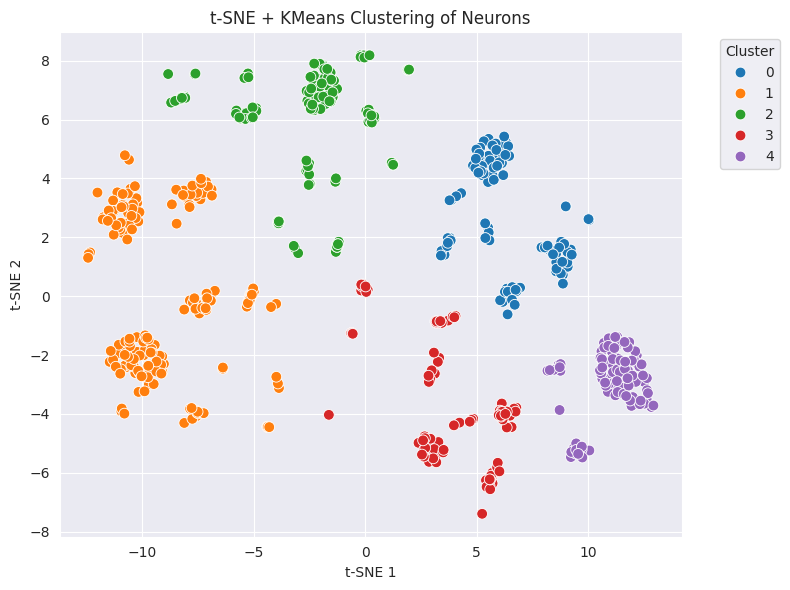

In [26]:
filtered_df = (
        significant_results
        .sort_values('R-squared', ascending=False)
        .drop_duplicates(['NeuronID', 'Behavior'])
    )
filtered_df = filtered_df.reset_index(drop=True)
# Step 1: pivot (NeuronID × Behavior) wide format 만들기
pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior', values='R-squared').fillna(0)

# pivot_df[pivot_df < 0.05] = 0
pivot_df = pivot_df[(pivot_df > 0).sum(axis=1) >= 2]

# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(pivot_df)
# t-SNE
tsne = TSNE(n_components=2, perplexity=100, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pivot_df)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

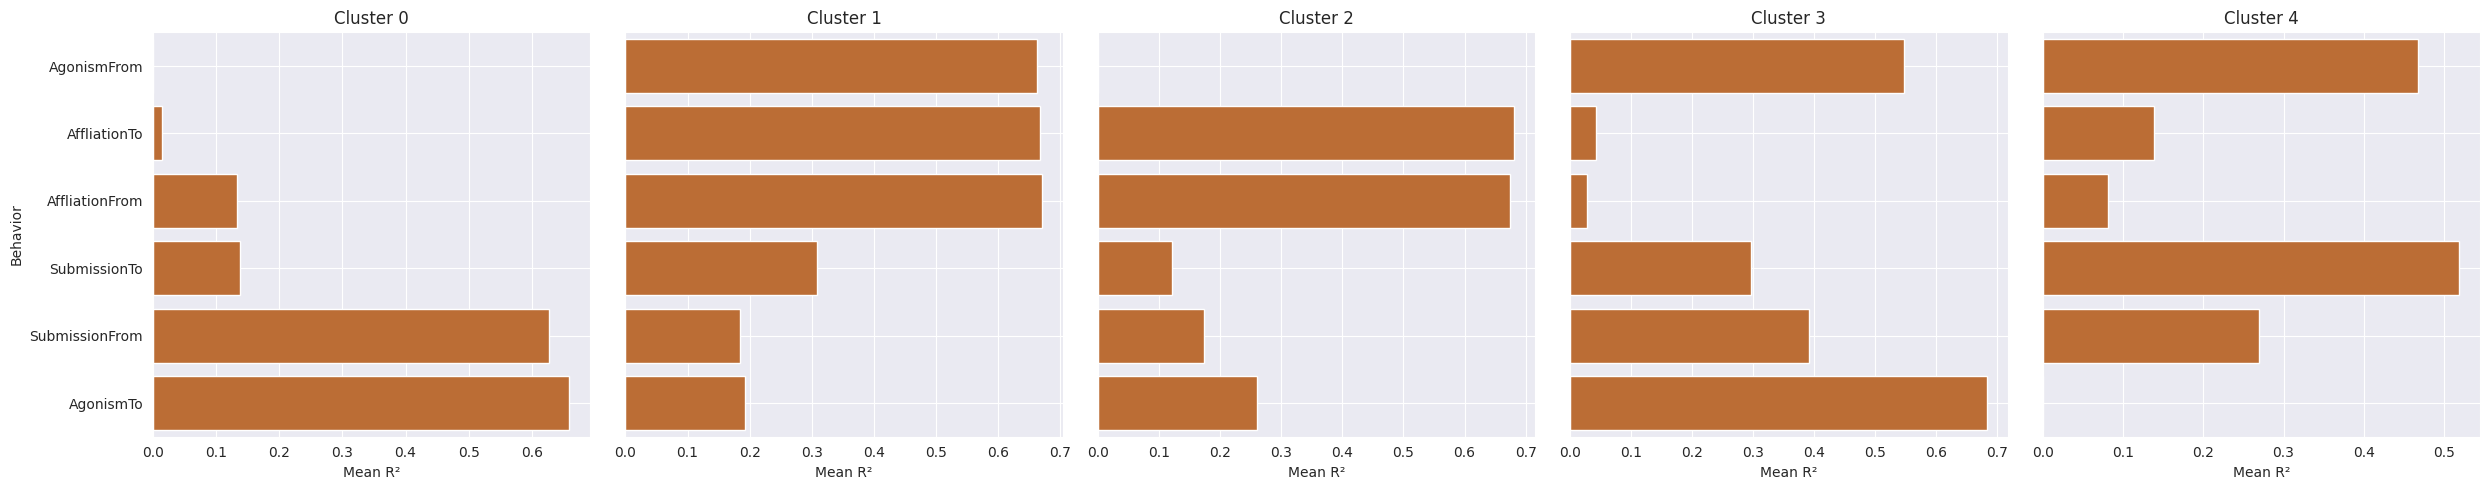

In [24]:
cluster_series = pd.Series(cluster_labels)
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels
n_clusters = cluster_series.nunique()
# Figure setup
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5), sharey=True)

for i, cluster_id in enumerate(sorted(cluster_series.unique())):
    ax = axes[i] if n_clusters > 1 else axes

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean().sort_values(ascending=True)  # <- barh로 그릴거라서 ascending=True

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='chocolate')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i == 0:
        ax.set_ylabel("Behavior")
    else:
        ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()
